### import data

In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

In [24]:
data = pd.read_csv('./data/processed.csv')
X = data.drop('Attrition', axis=1)
y = data['Attrition']

### plot the heatmap to check dataset's linearity

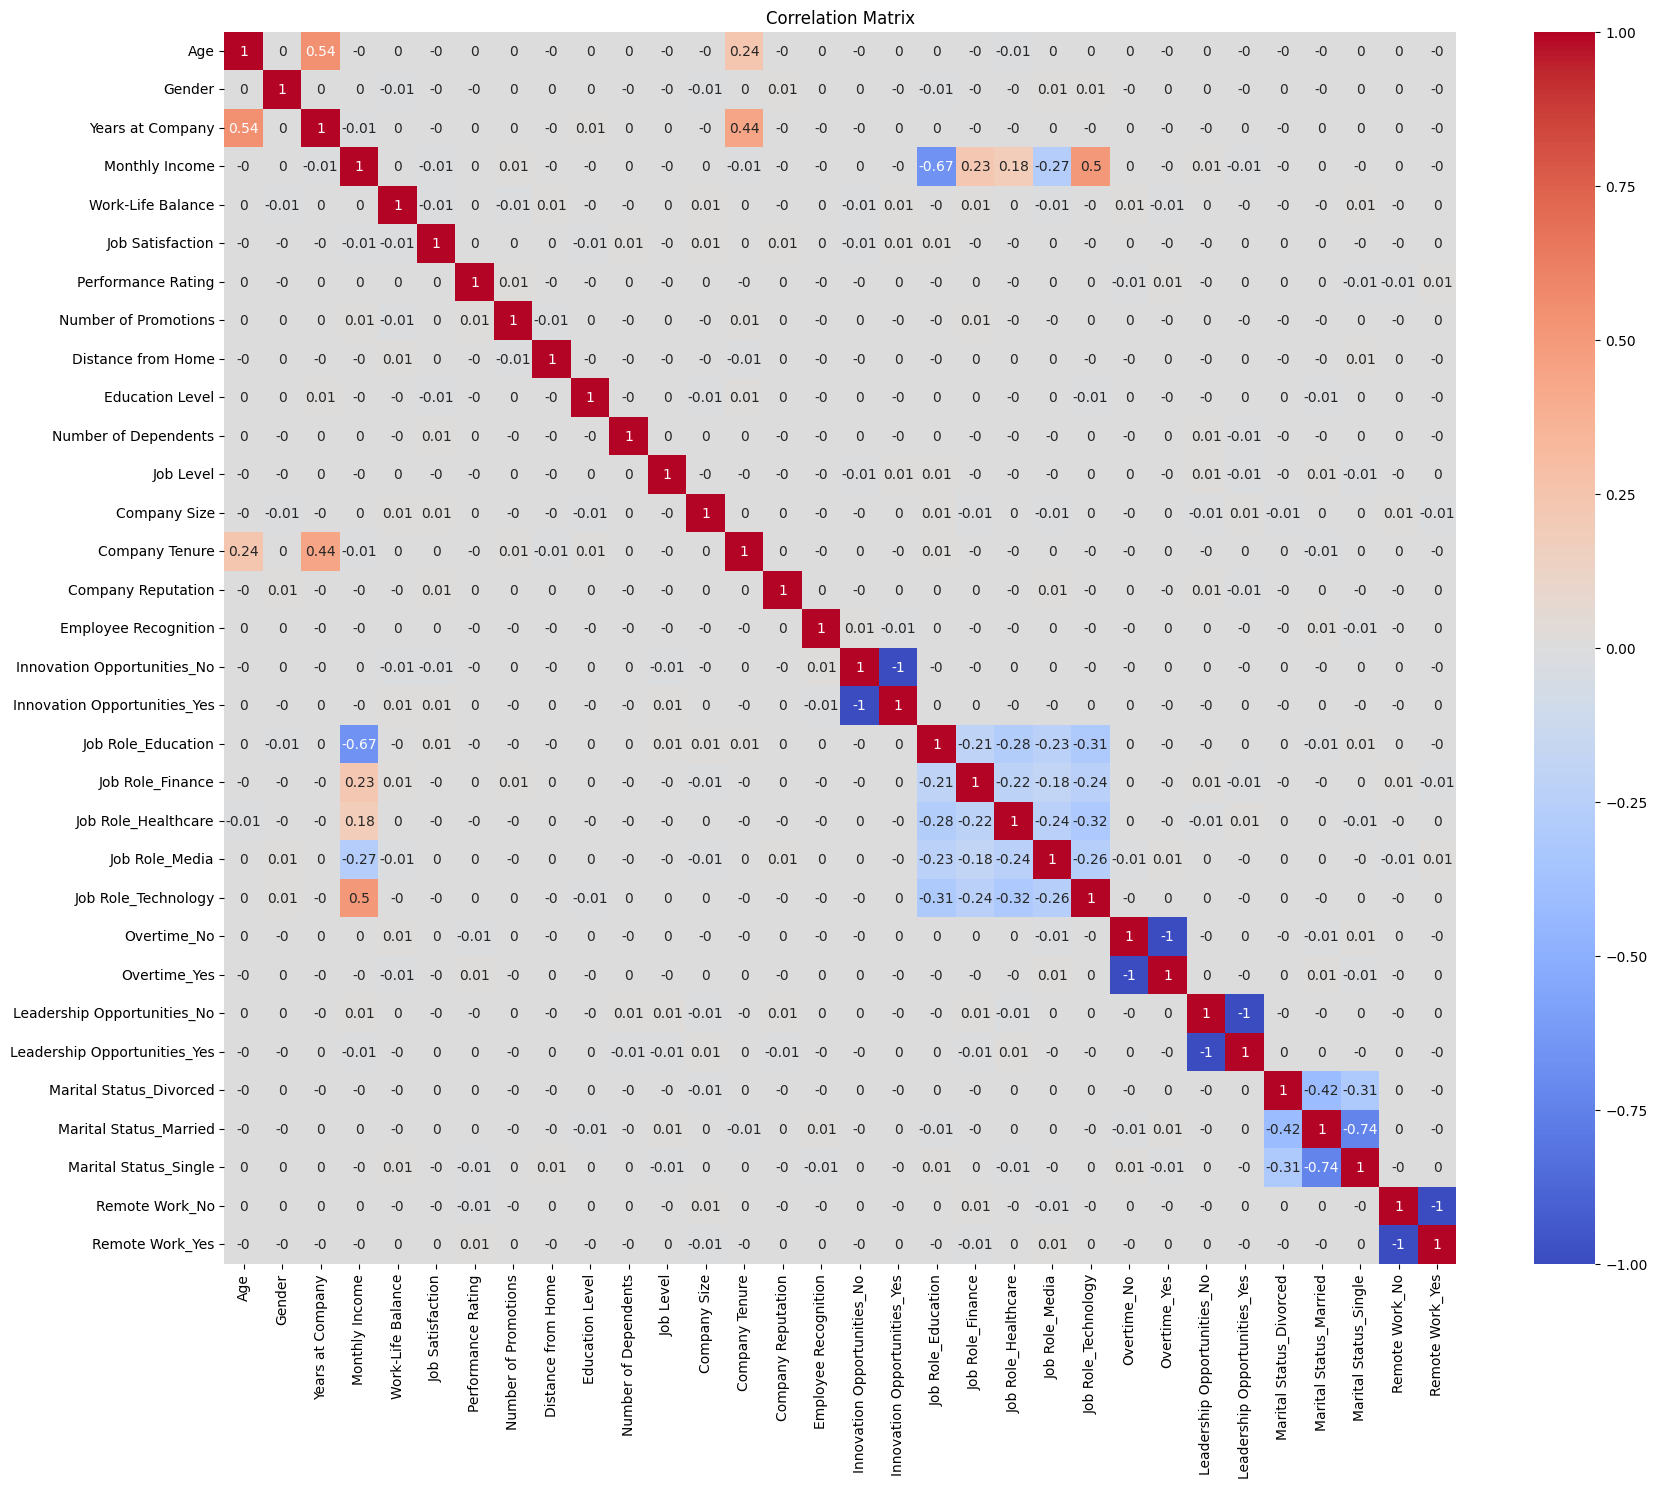

In [25]:
import seaborn as sns
correlation = X.corr().round(2)
plt.figure(figsize=(20, 16))
sns.heatmap(correlation, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

doesn't seems linear, that could explains why data post pca seems to overlap while data post umap don't (doesn't explain the strange shape tho)

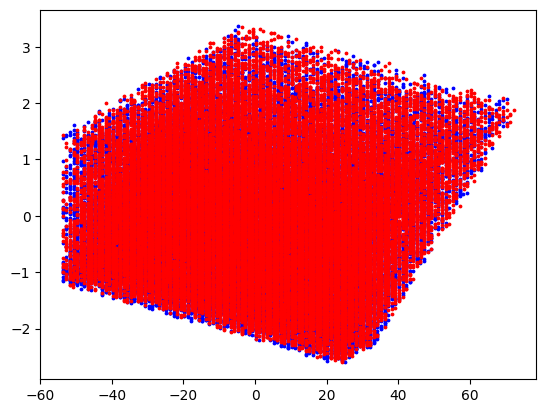

In [26]:
pca = PCA(n_components=2)
X_t= pd.DataFrame(pca.fit_transform(X))

plt.scatter(X_t.loc[y==0,0], X_t.loc[y==0,1], c='blue', s=3)
plt.scatter(X_t.loc[y==1,0], X_t.loc[y==1,1], c='red', s=3)
plt.show()

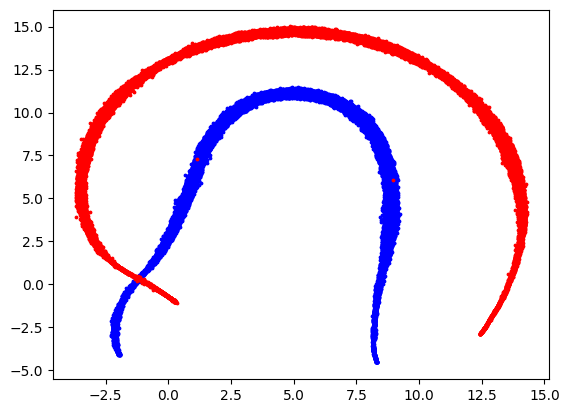

In [27]:
um = umap.UMAP(n_components=2)
X_t = pd.DataFrame(um.fit_transform(X, y))

plt.scatter(X_t.loc[y==0,0], X_t.loc[y==0,1], c='blue', s=3)
plt.scatter(X_t.loc[y==1,0], X_t.loc[y==1,1], c='red', s=3)
plt.show()

explained variance of (0,1): 646.6917464545304


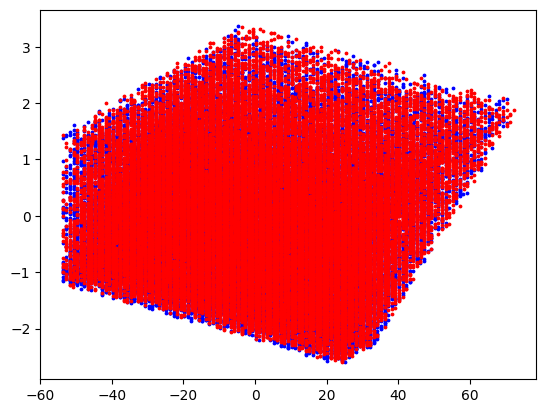

explained variance of (2,3): 2.1748323765338378


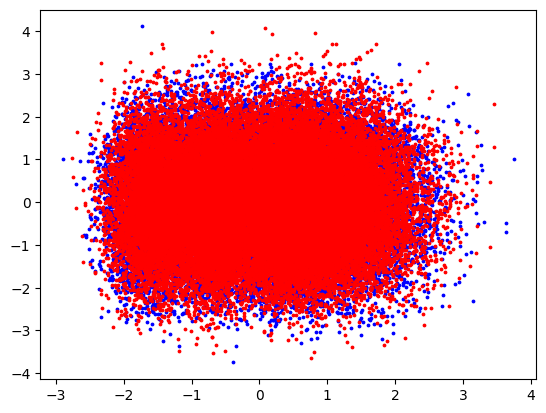

explained variance of (4,5): 2.026057240012785


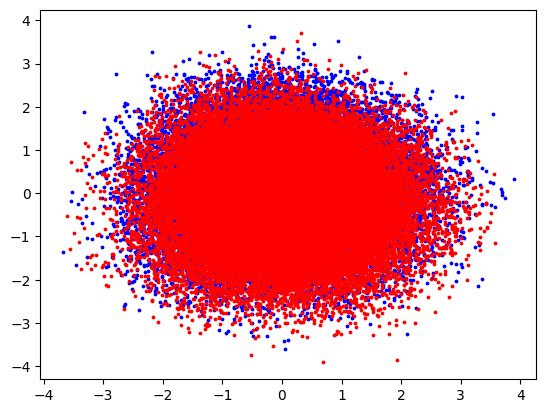

In [28]:
pca = PCA(n_components=6)
X_t = pca.fit_transform(X)
for i in range(0, 6, 2):
    plt.scatter(X_t[y==0,i], X_t[y==0,i+1], c='blue', s=3)
    plt.scatter(X_t[y==1,i], X_t[y==1,i+1], c='red', s=3)
    print(f'explained variance of ({i},{i+1}): {pca.explained_variance_[i] + pca.explained_variance_[i+1]}')
    plt.show()

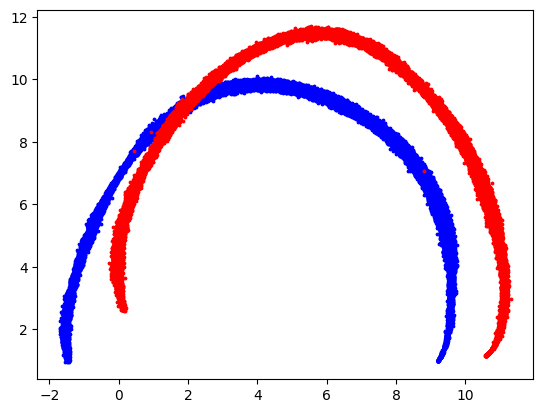

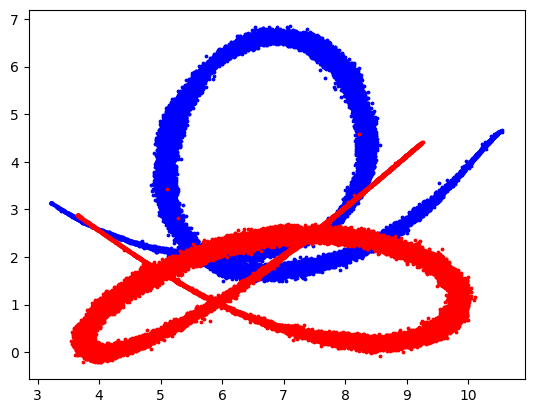

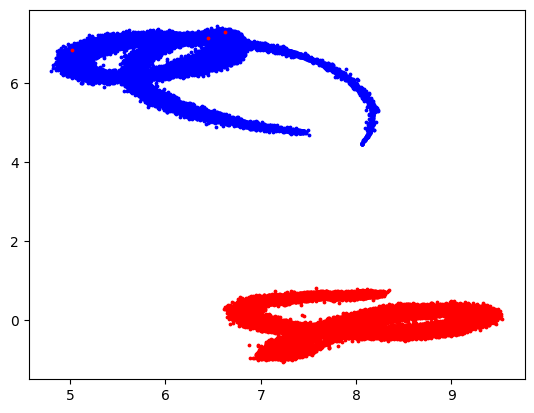

In [29]:

umap1 = umap.UMAP(n_components=6)
X_t = umap1.fit_transform(X, y)
for i in range(0, 6, 2):
    plt.scatter(X_t[y==0,i], X_t[y==0,i+1], c='blue', s=3)
    plt.scatter(X_t[y==1,i], X_t[y==1,i+1], c='red', s=3)
    plt.show()

In [30]:
from IPython.display import HTML
HTML(f"<style>td {{white-space: nowrap !important;}}</style>") 

In [31]:
from sklearn.model_selection import KFold
X_train, X_valid, Y_train, Y_valid= train_test_split(X, y, test_size=0.2, shuffle=True, random_state=420960)

def print_metrics(arr):
  df = pd.DataFrame((['train', arr[0, 0], arr[0, 1], arr[0, 2]], ['valid',arr[1, 0], arr[1, 1], arr[1, 2]]), columns=['set', 'accuracy', 'precision', 'recall']) 
  display(df)

def calc_metrics(X_train, X_valid, y_train, y_valid, model):
  train_pred = model.predict(X_train)
  valid_pred = model.predict(X_valid)
  acc_train= accuracy_score(y_train, train_pred)
  acc_valid= accuracy_score(y_valid, valid_pred)
  prec_train= precision_score(y_train, train_pred)
  prec_valid= precision_score(y_valid, valid_pred)
  rec_train= recall_score(y_train, train_pred)
  rec_valid= recall_score(y_valid, valid_pred)

  arr = [[acc_train, prec_train, rec_train], [acc_valid, prec_valid, rec_valid]]
  return arr


def kfold(X, Y, model, splits):
  kf = KFold(splits)
  metrics = np.zeros((2, 3))
  for train_indices, valid_indices in kf.split(X, Y):

    X_train, X_valid, Y_train, Y_valid = [X.iloc[train_indices], X.iloc[valid_indices], Y[train_indices], Y[valid_indices]]
    model.fit(X_train, Y_train)
    metrics += calc_metrics(X_train, X_valid, Y_train, Y_valid, model)

  metrics /= splits   
  print(model, end="") 
  display(pd.DataFrame([['train', metrics[0,0], metrics[0,1], metrics[0,2]], ['validation', metrics[1,0], metrics[1,1], metrics[1,2]]], columns=['set', 'accuracy', 'precision', 'recall']))
  return model


In [32]:
# finding optimal value for k

# param_grid = {'n_neighbors': np.arange(21, (int)(np.sqrt(X.shape[0])), 2)}
# knn = KNeighborsClassifier()
# from sklearn.model_selection import GridSearchCV
# grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)
# grid_search.fit(X_train, Y_train)
# print(grid_search.best_params_) # 267
k = 207

In [33]:
# finding optimal setting for ann hidden layer

# param_grid = {'hidden_layer_sizes': [(8,), (16,), (32,), (64), (128,), (8, 8), (16, 16), (32, 32)] }
# ann = MLPClassifier(learning_rate='adaptive', max_iter=1000)
# from sklearn.model_selection import GridSearchCV
# grid_search = GridSearchCV(ann, param_grid, cv=5, n_jobs=-1)
# grid_search.fit(X_train, Y_train)
# print(grid_search.best_params_) # (32,) 
hidden_layer = (32,)

#### train:validation = 4:1, pen=none, pre dim reduction

In [42]:
model = []
folds = [4, 5, 6]

In [43]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  model.append(kfold(X, y, KNeighborsClassifier(n_neighbors=k), i))
  model.append(kfold(X, y, LogisticRegression(max_iter=1000), i))
  model.append(kfold(X, y, MLPClassifier(hidden_layer_sizes=hidden_layer, learning_rate='adaptive', max_iter=1000), i))

------------------------------------4 folds------------------------------------
KNeighborsClassifier(n_neighbors=207)

,set,accuracy,precision,recall
0,train,0.724319,0.738706,0.735160
1,validation,0.715684,0.730442,0.726951


LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740767,0.749657,0.760342
1,validation,0.740382,0.749408,0.759737


MLPClassifier(hidden_layer_sizes=(32,), learning_rate='adaptive', max_iter=1000)

...

,set,accuracy,precision,recall
0,train,0.725187,0.740007,0.735010
1,validation,0.716932,0.732183,0.726939


LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740774,0.749691,0.760293
1,validation,0.740490,0.749383,0.760051


MLPClassifier(hidden_layer_sizes=(32,), learning_rate='adaptive', max_iter=1000)

,set,accuracy,precision,recall
0,train,0.753126,0.763624,0.770527
1,validation,0.748879,0.759360,0.766818


In [36]:
X_t = pd.DataFrame(PCA().fit_transform(X))

In [37]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  model.append(kfold(X_t, y, KNeighborsClassifier(n_neighbors=k), i))
  model.append(kfold(X_t, y, LogisticRegression(max_iter=1000), i))
  model.append(kfold(X_t, y, MLPClassifier(hidden_layer_sizes=hidden_layer, learning_rate='adaptive', max_iter=1000), i))

------------------------------------4 folds------------------------------------
KNeighborsClassifier(n_neighbors=207)

,set,accuracy,precision,recall
0,train,0.724319,0.738706,0.735160
1,validation,0.715684,0.730442,0.726951


LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740776,0.749678,0.760325
1,validation,0.740369,0.749377,0.759762


MLPClassifier(hidden_layer_sizes=(32,), learning_rate='adaptive', max_iter=1000)

...

,set,accuracy,precision,recall
0,train,0.725187,0.740007,0.735010
1,validation,0.716932,0.732183,0.726939


LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740782,0.749710,0.760278
1,validation,0.740369,0.749239,0.760001


MLPClassifier(hidden_layer_sizes=(32,), learning_rate='adaptive', max_iter=1000)

,set,accuracy,precision,recall
0,train,0.757650,0.767685,0.772324
1,validation,0.749658,0.759842,0.765191


In [38]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  model.append(kfold(X, y, LogisticRegression(max_iter=1000, penalty='l2'), i))

------------------------------------4 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740767,0.749657,0.760342
1,validation,0.740382,0.749408,0.759737


------------------------------------5 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740953,0.749848,0.760484
1,validation,0.740691,0.749789,0.759839


------------------------------------6 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740774,0.749691,0.760293
1,validation,0.740490,0.749383,0.760051


In [39]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  model.append(kfold(X_t, y, LogisticRegression(max_iter=1000, penalty='l2'), i))

------------------------------------4 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740776,0.749678,0.760325
1,validation,0.740369,0.749377,0.759762


------------------------------------5 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740973,0.749873,0.760490
1,validation,0.740664,0.749751,0.759839


------------------------------------6 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision,recall
0,train,0.740782,0.749710,0.760278
1,validation,0.740369,0.749239,0.760001


### model visualization and selection, using models with 4:1 split ratio, no pen, post dim reduction

knn roc curve:


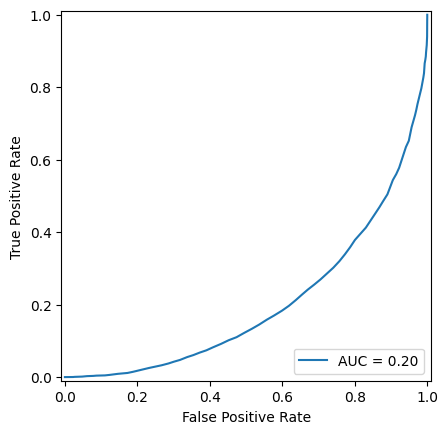

lr roc curve:


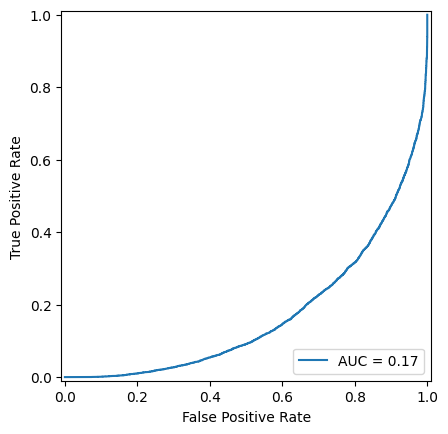

ann roc curve:


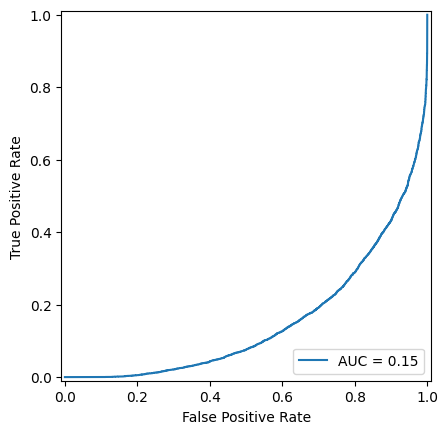

In [40]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay
X_train, X_valid, Y_train, Y_valid = train_test_split(X_t, y, test_size=0.2, shuffle=True, random_state=420)
knn_pred_proba = model[9].predict_proba(X_valid)
lr_pred_proba = model[10].predict_proba(X_valid)
ann_pred_proba = model[11].predict_proba(X_valid)


print("knn roc curve:")
fpr, tpr, _ = roc_curve(Y_valid, knn_pred_proba[:,0])
roc_auc = auc(fpr, tpr)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.show()


print("lr roc curve:")
fpr, tpr, _ = roc_curve(Y_valid, lr_pred_proba[:, 0])
roc_auc = auc(fpr, tpr)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.show()


print("ann roc curve:")
fpr, tpr, _ = roc_curve(Y_valid, ann_pred_proba[:,0])
roc_auc = auc(fpr, tpr)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.show()

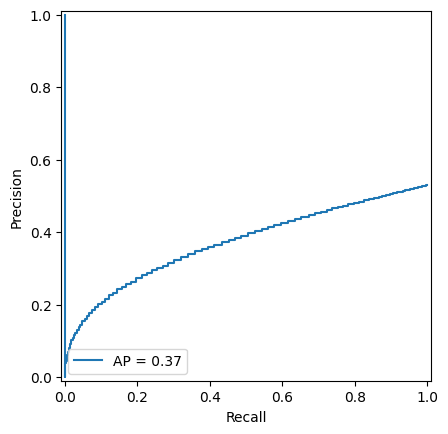

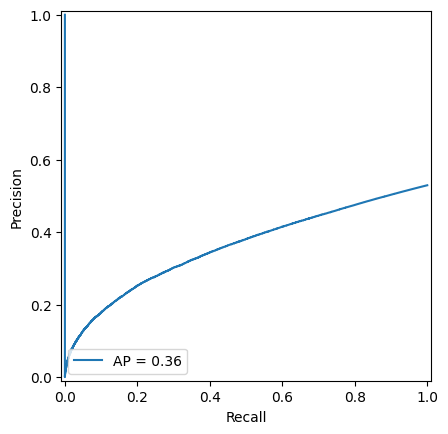

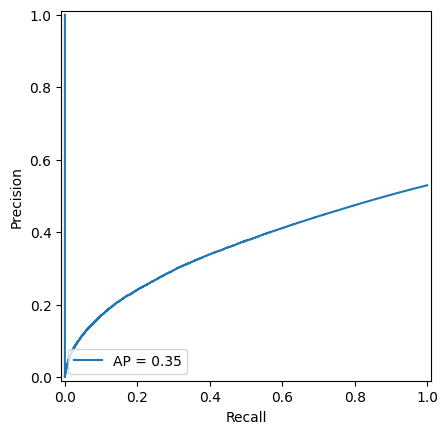

In [41]:

prec, rec, threshold = precision_recall_curve(Y_valid, knn_pred_proba[:,0])
pr_auc = auc(rec, prec)

pr_display = PrecisionRecallDisplay(prec, rec, average_precision=pr_auc)
pr_display.plot()
plt.show()



prec, rec, threshold = precision_recall_curve(Y_valid, lr_pred_proba[:,0])
pr_auc = auc(rec, prec)

pr_display = PrecisionRecallDisplay(prec, rec, average_precision=pr_auc)
pr_display.plot()
plt.show()



prec, rec, threshold = precision_recall_curve(Y_valid, ann_pred_proba[:,0])
pr_auc = auc(rec, prec)

pr_display = PrecisionRecallDisplay(prec, rec, average_precision=pr_auc)
pr_display.plot()
plt.show()